### Adaptive Corrective RAG

# Adaptive Corrective RAG using LangGraph

## Goal

This notebook implements an **Adaptive Corrective RAG** system.

The system can:

1. **Adaptively route** the user question to the right knowledge source.
2. **Retrieve documents** from a FAISS vectorstore.
3. **Grade retrieved documents** for relevance.
4. **Correct itself** if the retrieved documents are not useful.
5. **Rewrite the query** and retry retrieval.
6. **Fallback to Wikipedia** if vectorstore retrieval fails.
7. **Generate a final answer** using the best available context.

---

## What is Adaptive RAG?

Adaptive RAG means the system does not always use the same retrieval path.

Instead, it first understands the question and decides:

- Should I search my internal vector database?
- Should I use an external knowledge source like Wikipedia?

In this project:

- Questions about LangChain, LangGraph, RAG, agents, tools, embeddings, and model providers go to the **FAISS vectorstore**.
- General knowledge questions go to **Wikipedia**.

---

## What is Corrective RAG?

Corrective RAG means the system checks whether the retrieved documents are actually useful.

If the documents are relevant:

- The system generates the final answer.

If the documents are not relevant:

- The system rewrites the query.
- It retrieves again.
- If it still fails after retries, it falls back to Wikipedia.

This prevents the model from blindly answering using bad context.

Added Cache Implementation using FAISS Semantic Cache

---

## Graph Flow

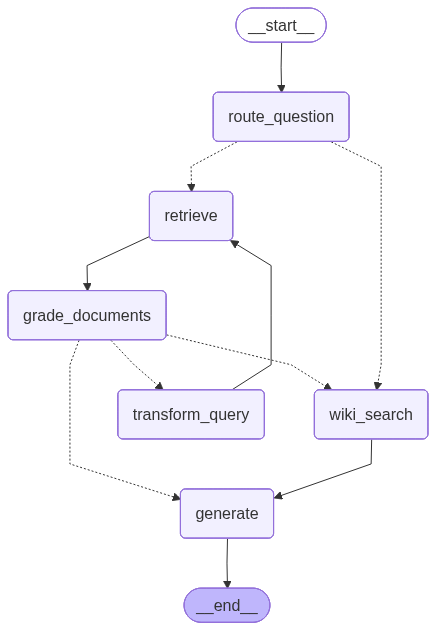

In [ ]:
import os
from  typing import List , Annotated, TypedDict, Sequence, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from  typing import List , Annotated, TypedDict, Sequence, Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_groq import ChatGroq

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()




In [ ]:
# Initialize global ChatGroq model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")


In [ ]:
### 1. Document Processing

urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

loaders = [WebBaseLoader(url) for url in urls]

docs=[]

for loader in loaders:
    docs.extend(loader.load())

docs

In [ ]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

In [ ]:
from langchain_community.utilities import WikipediaAPIWrapper
# External Tool: Wikipedia

wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1500)

In [ ]:
from typing import Dict, List
from pydantic import BaseModel, Field

class AdaptiveCorrectiveRAGState(TypedDict):
    question: str
    retrieval_mode: str
    query: str
    documents: List[Document]
    doc_score: str
    answer: str
    retry_count: int

In [ ]:
# Add Structured output

class RouteQuery(BaseModel):
    datasource: Literal["vectorstore", "wiki_search"] = Field(
        description="Route to vectorstore if question is about LangChain docs, otherwise wiki_search"
    )


class GradeDocuments(BaseModel):
    binary_score: Literal["yes", "no"] = Field(
        description="yes if document is relevant to the question, otherwise no"
    )

In [ ]:
# Create Question Router

structured_llm_router = llm.with_structured_output(RouteQuery)

route_prompt = PromptTemplate(
    template="""
You are an expert at routing a user question.

Use vectorstore for questions about:
- LangChain
- LangGraph
- agents
- RAG
- retrievers
- tools
- embeddings
- model providers

Use wiki_search for general world knowledge.

Question: {question}
""",
    input_variables=["question"],
)

question_router = route_prompt | structured_llm_router


In [ ]:
structured_llm_grader = llm.with_structured_output(GradeDocuments)

grade_prompt = PromptTemplate(
    template="""
You are grading whether a retrieved document is relevant to a user question.

Retrieved document:
{document}

User question:
{question}

Return yes if relevant. Return no if not relevant.
""",
    input_variables=["document", "question"],
)

retrieval_grader = grade_prompt | structured_llm_grader

In [ ]:
# Create Query writer
rewrite_prompt = PromptTemplate(
    template="""
You are rewriting a question to improve retrieval.

Original question:
{question}

Rewrite the question so it is more specific and retrieval-friendly.
Only return the rewritten question.
""",
    input_variables=["question"],
)

question_rewriter = rewrite_prompt | llm | StrOutputParser()

In [ ]:
# create answer generator

generate_prompt = PromptTemplate(
    template="""
You are an AI assistant. Answer the question using only the provided context.

Question:
{question}

Context:
{context}

Answer:
""",
    input_variables=["question", "context"],
)

rag_chain = generate_prompt | llm | StrOutputParser()

In [ ]:
# create graph nodes

def route_question_node(state: AdaptiveCorrectiveRAGState):
    print("---ROUTE QUESTION---")

    question = state["question"]
    route = question_router.invoke({"question": question})

    return {
        "retrieval_mode": route.datasource,
        "query": question,
        "retry_count": 0
    }

In [ ]:
def retrieve_node(state: AdaptiveCorrectiveRAGState):
    print("---RETRIEVE FROM VECTORSTORE---")

    query = state["query"]
    documents = retriever.invoke(query)

    return {
        "documents": documents
    }

In [ ]:
def wiki_search_node(state: AdaptiveCorrectiveRAGState):
    print("---WIKI SEARCH---")

    question = state["question"]
    wiki_result = wiki.run(question)

    doc = Document(page_content=wiki_result)

    return {
        "documents": [doc],
        "doc_score": "yes"
    }

In [ ]:
def grade_documents_node(state: AdaptiveCorrectiveRAGState):
    print("---GRADE DOCUMENTS---")

    question = state["question"]
    documents = state["documents"]

    filtered_docs = []

    for doc in documents:
        score = retrieval_grader.invoke({
            "question": question,
            "document": doc.page_content
        })

        if score.binary_score == "yes":
            filtered_docs.append(doc)

    if filtered_docs:
        return {
            "documents": filtered_docs,
            "doc_score": "yes"
        }

    return {
        "documents": [],
        "doc_score": "no"
    }

In [ ]:
def transform_query_node(state: AdaptiveCorrectiveRAGState):
    print("---TRANSFORM QUERY---")

    question = state["question"]
    retry_count = state["retry_count"] + 1

    better_query = question_rewriter.invoke({
        "question": question
    })

    return {
        "query": better_query,
        "retry_count": retry_count
    }

In [ ]:
def generate_node(state: AdaptiveCorrectiveRAGState):
    print("---GENERATE ANSWER---")

    question = state["question"]
    documents = state["documents"]

    context = "\n\n".join([doc.page_content for doc in documents])

    answer = rag_chain.invoke({
        "question": question,
        "context": context
    })

    return {
        "answer": answer
    }

In [ ]:
# Add routing functions
def decide_retrieval_source(state: AdaptiveCorrectiveRAGState):
    if state["retrieval_mode"] == "wiki_search":
        return "wiki_search"

    return "retrieve"

In [ ]:
def decide_to_generate(state: AdaptiveCorrectiveRAGState):
    print("---DECIDE TO GENERATE---")

    if state["doc_score"] == "yes":
        return "generate"

    if state["retry_count"] < 2:
        return "transform_query"

    return "wiki_search"

In [ ]:
# Gra[h Construction

workflow = StateGraph(AdaptiveCorrectiveRAGState)

workflow.add_node("route_question", route_question_node)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("wiki_search", wiki_search_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("transform_query", transform_query_node)
workflow.add_node("generate", generate_node)

workflow.add_edge(START, "route_question")

workflow.add_conditional_edges(
    "route_question",
    decide_retrieval_source,
    {
        "retrieve": "retrieve",
        "wiki_search": "wiki_search"
    }
)

workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "transform_query": "transform_query",
        "wiki_search": "wiki_search"
    }
)

workflow.add_edge("transform_query", "retrieve")
workflow.add_edge("wiki_search", "generate")
workflow.add_edge("generate", END)

graph = workflow.compile()

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Cache Implementation 
- LangChain’s FAISS vectorstore supports adding new documents with add_documents and searching similar documents with similarity_search_with_score, which is used for semantic cache lookup 
- Semantic Cahe: Similar question → reuse answer

In [ ]:
from datetime import datetime
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS

In [26]:
# Dummy document is used to initialize FAISS cache.
# Later, real question-answer pairs will be added.

dummy_cache_doc = Document(
    page_content="initial semantic cache document",
    metadata={
        "question": "initial semantic cache document",
        "answer": "initial semantic cache answer",
        "source": "dummy"
    }
)

semantic_cache = FAISS.from_documents(
    documents=[dummy_cache_doc],
    embedding=embedding
)

In [27]:
# Cache Lookup Function
def lookup_semantic_cache(question: str, threshold: float = 0.25):
    """
    Looks for a semantically similar question in FAISS cache.

    Args:
        question: Current user question.
        threshold: Similarity distance threshold.

    Returns:
        Cached answer if similar question is found.
        None if cache miss.

    Note:
        With FAISS similarity_search_with_score, lower score usually means
        more similar when using L2 distance.
    """

    results = semantic_cache.similarity_search_with_score(
        query=question,
        k=1
    )

    if not results:
        return None

    matched_doc, score = results[0]

    print("---SEMANTIC CACHE CHECK---")
    print("Matched cached question:", matched_doc.metadata.get("question"))
    print("Similarity score:", score)

    # Ignore dummy cache document
    if matched_doc.metadata.get("source") == "dummy":
        return None

    if score <= threshold:
        print("---CACHE HIT---")
        return matched_doc.metadata.get("answer")

    print("---CACHE MISS---")
    return None

In [28]:
# update Cache with latest response
def update_semantic_cache(question: str, answer: str):
    """
    Stores a new question-answer pair into FAISS semantic cache.
    """

    cache_doc = Document(
        page_content=question,
        metadata={
            "question": question,
            "answer": answer,
            "created_at": datetime.now().isoformat(),
            "source": "adaptive_corrective_rag"
        }
    )

    semantic_cache.add_documents([cache_doc])

    print("---CACHE UPDATED---")

In [36]:
def cached_graph_invoke(inputs: dict):
    """
    Wrapper around graph.invoke() that first checks
    the semantic cache.
    """

    question = inputs["question"]

    # Step 1: Check semantic cache
    cached_answer = lookup_semantic_cache(question)

    if cached_answer:
        print("=== CACHE HIT ===")

        # Return exactly the same structure as graph.invoke()
        inputs["answer"] = cached_answer
        inputs["cache_status"] = "hit"

        return inputs

    print("=== CACHE MISS ===")

    # Step 2: Execute Adaptive Corrective RAG
    result = graph.invoke(inputs)

    # Step 3: Store answer in cache
    update_semantic_cache(
        question=question,
        answer=result["answer"]
    )

    result["cache_status"] = "miss"

    return result

In [38]:
inputs = {
    "question": "What is LangGraph and how does it help build agents?",
    "retrieval_mode": "",
    "query": "",
    "documents": [],
    "doc_score": "",
    "answer": "",
    "retry_count": 0
}

result = cached_graph_invoke(inputs)
print(result["cache_status"])
print(result["answer"])

---SEMANTIC CACHE CHECK---
Matched cached question: What is LangGraph and how does it help build agents?
Similarity score: 0.000566003
---CACHE HIT---
=== CACHE HIT ===
hit
<think>
Okay, I need to figure out what LangGraph is and how it helps build agents based on the provided context. Let me start by reading through the context again carefully.

The first part says that LangChain's agents are built on top of LangGraph. It mentions that LangGraph provides durable execution, human-in-the-loop support, persistence, and more. Then there's a section comparing LangChain, LangGraph, and Deep Agents. It suggests using Deep Agents for a "batteries-included" approach with features like context compression and subagent-spawning. LangChain is for a customizable harness, and LangGraph is the low-level orchestration framework for advanced needs combining deterministic and agentic workflows.

So, from this, LangGraph seems to be a framework that LangChain uses to build agents. The key points are dur

In [40]:
input2 = {
    "question": "who is Enstein?",
    "retrieval_mode": "",
    "query": "",
    "documents": [],
    "doc_score": "",
    "answer": "",
    "retry_count": 0
}

result = cached_graph_invoke(input2)
print(result["cache_status"])
print(result["answer"])

---SEMANTIC CACHE CHECK---
Matched cached question: What is LangGraph and how does it help build agents?
Similarity score: 0.5978441
---CACHE MISS---
=== CACHE MISS ===
---ROUTE QUESTION---
---WIKI SEARCH---
---GENERATE ANSWER---
---CACHE UPDATED---
miss
<think>
Okay, the user is asking "who is Enstein?" which seems like a typo for "Einstein." I need to check the provided context to form the answer. The context is about Albert Einstein, so the correct answer should be based on that.

First, the context states he's a German-born theoretical physicist known for the theory of relativity. Also mentioned are his contributions to quantum theory and the E=mc² equation. The key points to include are his birth and death dates, his notable works, the Nobel Prize, and some of his life events like moving to Switzerland and later to the US.

I should make sure not to include any information beyond the context. The user's typo might be a trick, but since the context only provides info on Albert Eins